# Asia Fetch QA: Geographic Bias + Visual Spot-Check

Two checks on the Asia fetch before treating it as final for the peer-reviewed dataset.

**Check 1 — Geographic distribution of kept tiles.** 
Plot the 18,441 surviving tiles on a map and bin per latitude. If they cluster in 
less-cloudy regions (northern/Central Asia, Mongolia, northern China, Korea) and 
tropical regions (Indonesia, Bangladesh, Philippines, southern India, Vietnam) are 
sparse, the low yield is cloud-driven — a documented, defensible geographic bias. 
If kept tiles are scattered uniformly across all of Asia, the yield loss came from 
something else (network, API errors) and warrants more investigation.

**Check 2 — Visual spot-check of random tiles.** 
Sample 30 random surviving tiles, render the S2 RGB composite, and inspect. 
Confirms tiles look like substations and aren't garbage that slipped through QC's 
lenient valid-pixel check.

## Dataset structure (assumed)

```
data/curated_datasets/dataset_asia_stac_v1/
├── _SUCCESS
├── manifest.json          # run-level metadata
├── summary.csv            # per-tile metadata, one row per surviving tile
└── images/
    └── {asset_id}_stac_{modality_combo}.npy   # (C, H, W) array per tile
```

Adjust `DATASET_DIR` and `ATTEMPTED_ASSETS_PATH` below if needed.

## Setup

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Paths — adjust if your repo layout differs.
DATASET_DIR           = Path("../data/curated_datasets/dataset_asia_stac_v1")
ATTEMPTED_ASSETS_PATH = Path("../data/PIPELINE/02-deduped-assets/asia_deduped_assets_substations.parquet")

SUMMARY_PATH  = DATASET_DIR / "summary.csv"
MANIFEST_PATH = DATASET_DIR / "manifest.json"
IMAGES_DIR    = DATASET_DIR / "images"

for p in [SUMMARY_PATH, MANIFEST_PATH, IMAGES_DIR, ATTEMPTED_ASSETS_PATH]:
    if not p.exists():
        print(f"⚠️  Missing: {p}")
    else:
        print(f"✓ Found:    {p}")

✓ Found:    ..\data\curated_datasets\dataset_asia_stac_v1\summary.csv
✓ Found:    ..\data\curated_datasets\dataset_asia_stac_v1\manifest.json
✓ Found:    ..\data\curated_datasets\dataset_asia_stac_v1\images
✓ Found:    ..\data\PIPELINE\02-deduped-assets\asia_deduped_assets_substations.parquet


In [6]:
# Load tables
summary = pd.read_csv(SUMMARY_PATH)

if ATTEMPTED_ASSETS_PATH.suffix == ".parquet":
    attempted = pd.read_parquet(ATTEMPTED_ASSETS_PATH)
else:
    attempted = pd.read_csv(ATTEMPTED_ASSETS_PATH)

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f"Attempted assets:  {len(attempted):,}")
print(f"Final tiles:       {len(summary):,}")
print(f"End-to-end yield:  {len(summary) / len(attempted) * 100:.1f}%")
print()
print(f"Modalities:        {manifest.get('modalities')}")
print(f"Modality counts:   {manifest.get('modality_counts')}")
print(f"Has temporal:      {manifest.get('has_temporal')}")
print()
print("Summary columns:   ", list(summary.columns))
print("Attempted columns: ", list(attempted.columns)[:10], "..." if len(attempted.columns) > 10 else "")

Attempted assets:  127,244
Final tiles:       18,441
End-to-end yield:  14.5%

Modalities:        ['sentinel1', 'sentinel2_ms']
Modality counts:   {'sentinel2_ms+sentinel1': 18441}
Has temporal:      False

Summary columns:    ['asset_id', 'asset_type', 'source', 'lat', 'lon', 'image_date', 'confidence', 'triage_reason', 'image_file', 'temporal_file', 'modalities', 'n_bands', 'n_timesteps']
Attempted columns:  ['asset_id', 'asset_type', 'lat', 'lon', 'name', 'source', 'osm_tags'] 


In [8]:
# Confirm attempted-assets table has lat/lon. Different upstream stages use
# different column names; try the most common ones.
ATTEMPTED_LAT = next((c for c in ("lat", "latitude", "centroid_y") if c in attempted.columns), None)
ATTEMPTED_LON = next((c for c in ("lon", "longitude", "centroid_x") if c in attempted.columns), None)

if ATTEMPTED_LAT is None or ATTEMPTED_LON is None:
    raise KeyError(
        f"Couldn't find lat/lon in attempted assets. Columns are: "
        f"{list(attempted.columns)}. Edit the cell above to specify the correct names."
    )
print(f"Attempted assets use: {ATTEMPTED_LAT}, {ATTEMPTED_LON}")
print(f"Surviving tiles use: lat, lon (from summary.csv)")

Attempted assets use: lat, lon
Surviving tiles use: lat, lon (from summary.csv)


## Check 1 — Geographic distribution

Three views:
1. Scatter map of attempted (gray) vs kept (red)
2. Per-cell yield heatmap on a 5° grid
3. Yield by latitude band — the cleanest cloud-cover signal

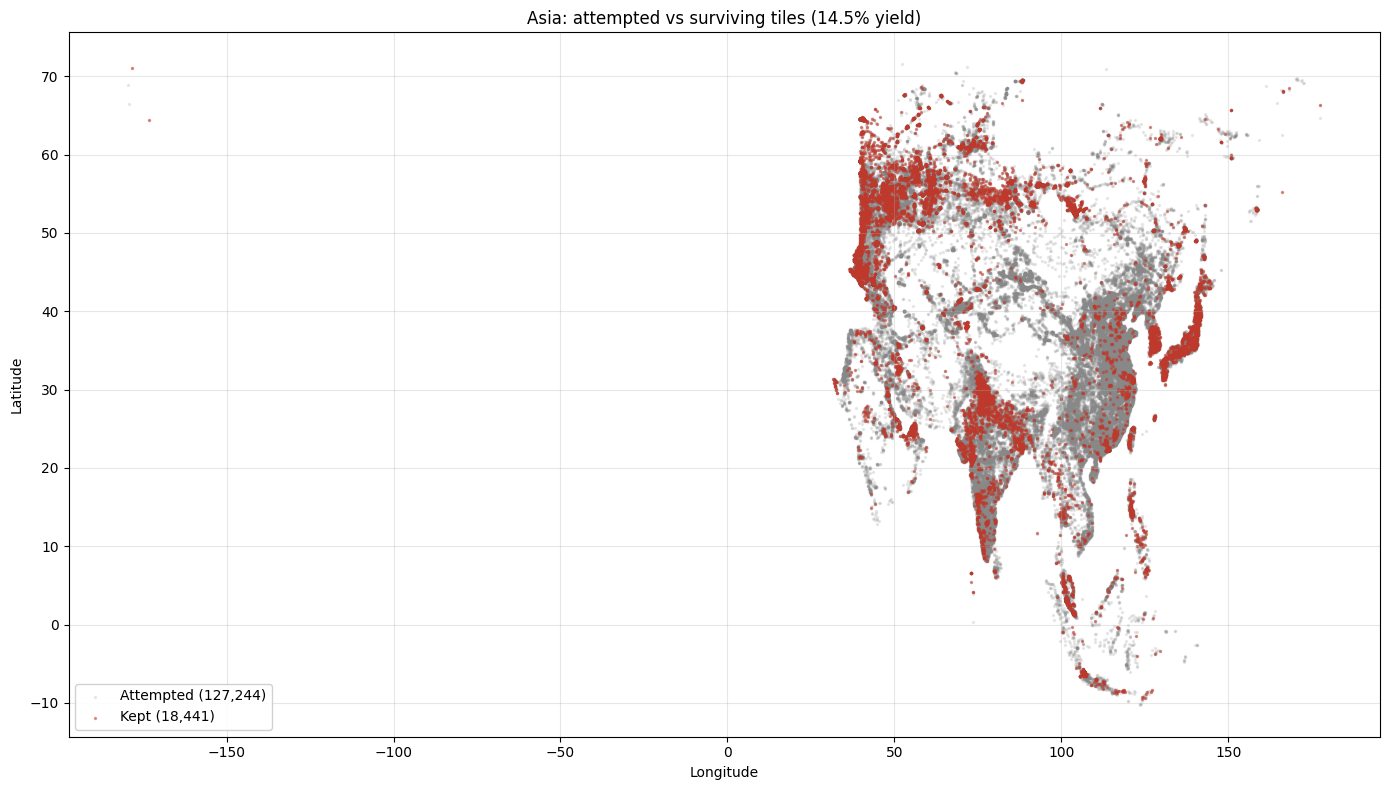

In [9]:
# 1. Scatter overlay
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(
    attempted[ATTEMPTED_LON], attempted[ATTEMPTED_LAT],
    s=2, alpha=0.15, color="#888888", label=f"Attempted ({len(attempted):,})"
)
ax.scatter(
    summary["lon"], summary["lat"],
    s=2, alpha=0.45, color="#c0392b", label=f"Kept ({len(summary):,})"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Asia: attempted vs surviving tiles ({len(summary)/len(attempted)*100:.1f}% yield)")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

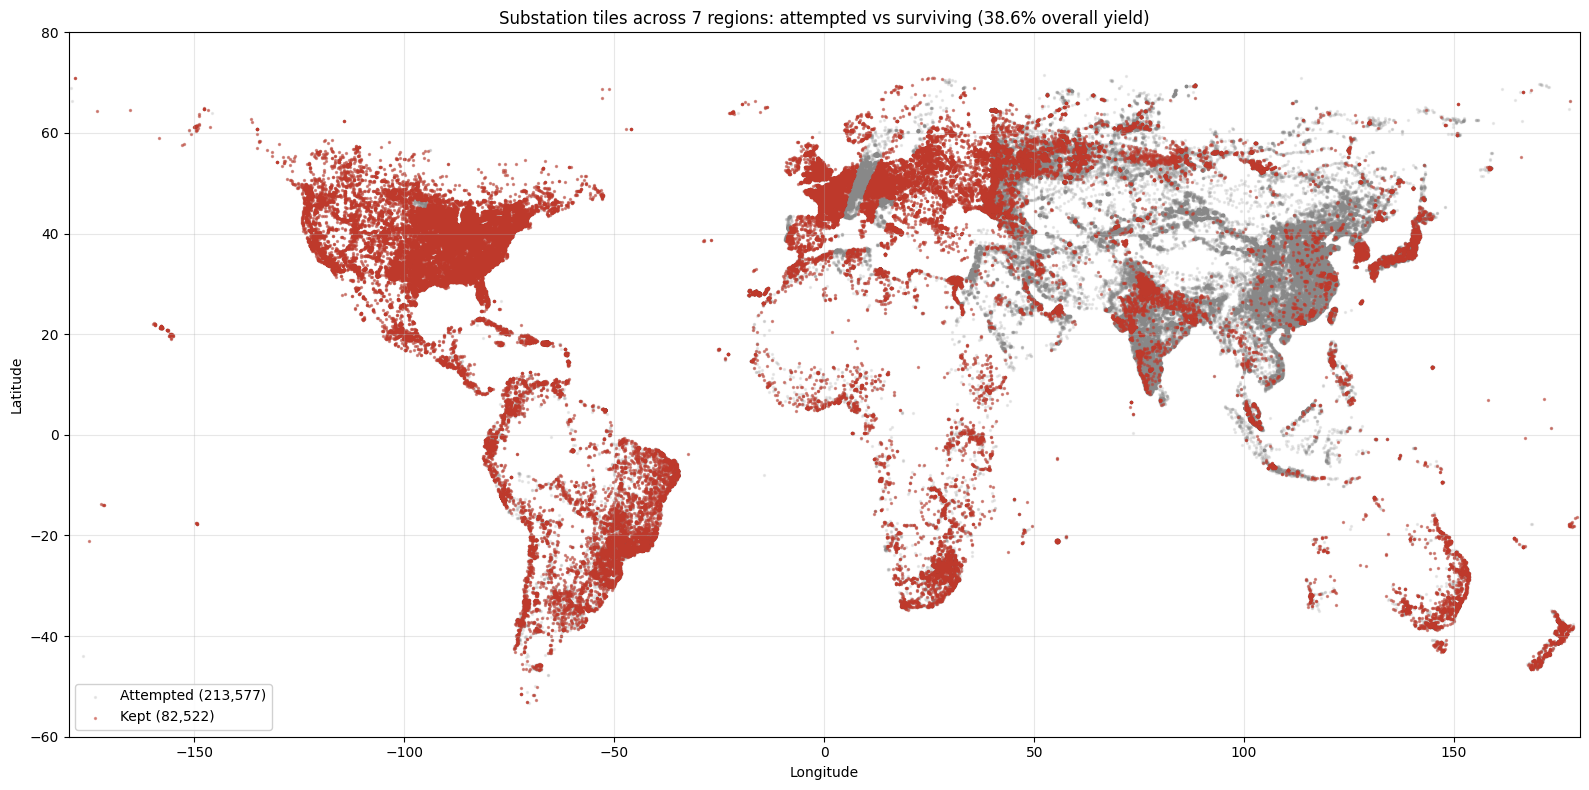


Per-region:
  region                  attempted         kept    yield %
  asia                      127,244       18,441      14.5%
  central_america             1,807        1,361      75.3%
  south_america              17,899       11,313      63.2%
  australia_oceania           5,583        3,257      58.3%
  africa                     11,044        5,869      53.1%
  europe                     25,000       17,622      70.5%
  north_america              25,000       24,659      98.6%


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Region -> (dataset_dir_name, deduped_assets_filename)
REGIONS = {
    "asia":              ("dataset_asia_stac_v1",              "asia_deduped_assets_substations.parquet"),
    "central_america":   ("dataset_central-america_stac_v1",   "central-america_deduped_assets_substations.parquet"),
    "south_america":     ("dataset_south-america_stac_v1",     "south-america_deduped_assets_substations.parquet"),
    "australia_oceania": ("dataset_australia-oceania_stac_v1", "australia-oceania_deduped_assets_substations.parquet"),
    "africa":            ("dataset_africa_stac_v1",            "africa_deduped_assets_substations.parquet"),
    "europe":            ("dataset_europe_stac_v1",            "europe_deduped_assets_substations_sampled.parquet"),
    "north_america":     ("dataset_north-america_stac_v1",     "north-america_deduped_assets_substations_sampled.parquet"),
}

DEDUPED_DIR  = Path("../data/PIPELINE/02-deduped-assets")
DATASETS_DIR = Path("../data/curated_datasets")

# Collect all attempted and kept points across regions
all_attempted = []
all_kept      = []
region_stats  = []

for region, (dataset_subdir, deduped_file) in REGIONS.items():
    deduped_path = DEDUPED_DIR / deduped_file
    summary_path = DATASETS_DIR / dataset_subdir / "summary.csv"

    if not deduped_path.exists():
        print(f"⚠️  {region}: missing deduped file at {deduped_path}")
        continue
    if not summary_path.exists():
        print(f"⚠️  {region}: missing summary.csv at {summary_path}")
        continue

    attempted = pd.read_parquet(deduped_path)
    kept      = pd.read_csv(summary_path)

    # Resolve lat/lon column names in attempted (kept always has lat/lon from summary.csv)
    lat_col = next((c for c in ("lat", "latitude", "centroid_y") if c in attempted.columns), None)
    lon_col = next((c for c in ("lon", "longitude", "centroid_x") if c in attempted.columns), None)
    if lat_col is None or lon_col is None:
        print(f"⚠️  {region}: couldn't find lat/lon cols in {list(attempted.columns)}")
        continue

    all_attempted.append(attempted[[lat_col, lon_col]].rename(columns={lat_col: "lat", lon_col: "lon"}))
    all_kept.append(kept[["lat", "lon"]])
    region_stats.append((region, len(attempted), len(kept), len(kept) / len(attempted) * 100))

attempted_all = pd.concat(all_attempted, ignore_index=True)
kept_all      = pd.concat(all_kept, ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.scatter(attempted_all["lon"], attempted_all["lat"],
           s=2, alpha=0.15, color="#888888",
           label=f"Attempted ({len(attempted_all):,})")
ax.scatter(kept_all["lon"], kept_all["lat"],
           s=2, alpha=0.45, color="#c0392b",
           label=f"Kept ({len(kept_all):,})")

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 80)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Substation tiles across {len(region_stats)} regions: "
    f"attempted vs surviving "
    f"({len(kept_all)/len(attempted_all)*100:.1f}% overall yield)"
)
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Per-region summary
print("\nPer-region:")
print(f"  {'region':<20} {'attempted':>12} {'kept':>12} {'yield %':>10}")
for region, n_att, n_kept, yield_pct in region_stats:
    print(f"  {region:<20} {n_att:>12,} {n_kept:>12,} {yield_pct:>9.1f}%")

Highest-yield cells (≥50 attempted):
 lat_bin  lon_bin  attempted  kept  yield_pct
     -10      105       1689   984  58.259325
      35       70        147    81  55.102041
      60      125         93    46  49.462366
      55       35        979   470  48.008172
      25      125         54    22  40.740741
      60       40        767   304  39.634941
      45       35       2530   935  36.956522
      50      100        830   299  36.024096
      50       35        130    46  35.384615
      10      120        438   153  34.931507

Lowest-yield cells (≥50 attempted):
 lat_bin  lon_bin  attempted  kept  yield_pct
      35       75        252     0   0.000000
      35       90        166     0   0.000000
      45       65         87     0   0.000000
      45       90         60     0   0.000000
      45       55         54     0   0.000000
      35       95        347     1   0.288184
      45       85        272     1   0.367647
      45      120        432     2   0.462963
      

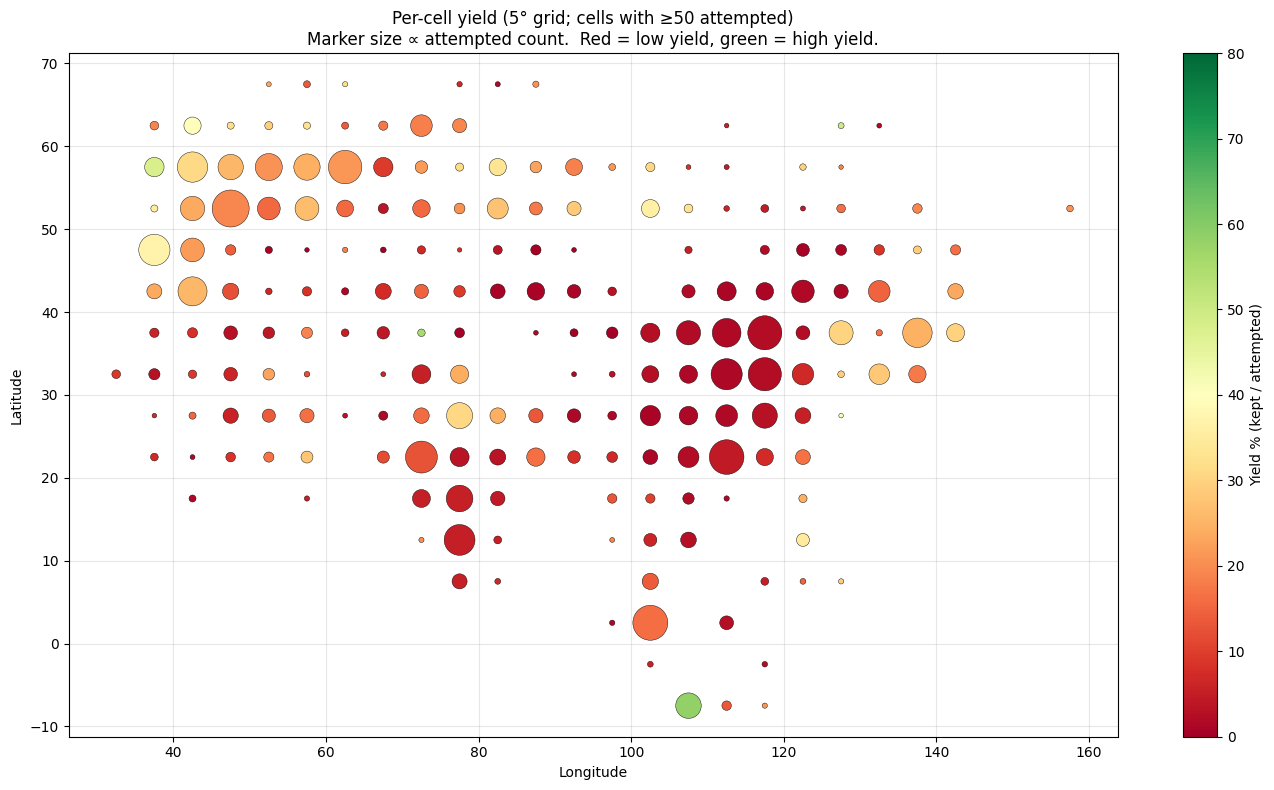

In [10]:
# 2. Per-cell yield on a 5° grid
BIN_DEG = 5

att_cells = pd.DataFrame({
    "lat_bin": (attempted[ATTEMPTED_LAT] // BIN_DEG * BIN_DEG).astype(int),
    "lon_bin": (attempted[ATTEMPTED_LON] // BIN_DEG * BIN_DEG).astype(int),
})
fin_cells = pd.DataFrame({
    "lat_bin": (summary["lat"] // BIN_DEG * BIN_DEG).astype(int),
    "lon_bin": (summary["lon"] // BIN_DEG * BIN_DEG).astype(int),
})

att_counts = att_cells.value_counts().rename("attempted").reset_index()
fin_counts = fin_cells.value_counts().rename("kept").reset_index()

yield_df = att_counts.merge(fin_counts, on=["lat_bin", "lon_bin"], how="left")
yield_df["kept"] = yield_df["kept"].fillna(0).astype(int)
yield_df["yield_pct"] = yield_df["kept"] / yield_df["attempted"] * 100
yield_df = yield_df[yield_df["attempted"] >= 50]   # filter noisy cells

print("Highest-yield cells (≥50 attempted):")
print(yield_df.nlargest(10, "yield_pct").to_string(index=False))
print("\nLowest-yield cells (≥50 attempted):")
print(yield_df.nsmallest(10, "yield_pct").to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 8))
sc = ax.scatter(
    yield_df["lon_bin"] + BIN_DEG / 2,
    yield_df["lat_bin"] + BIN_DEG / 2,
    c=yield_df["yield_pct"],
    s=yield_df["attempted"] / 5,
    cmap="RdYlGn",
    vmin=0, vmax=80,
    edgecolor="black", linewidth=0.3,
)
plt.colorbar(sc, ax=ax, label="Yield % (kept / attempted)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Per-cell yield ({BIN_DEG}° grid; cells with ≥50 attempted)\n"
    f"Marker size ∝ attempted count.  Red = low yield, green = high yield."
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

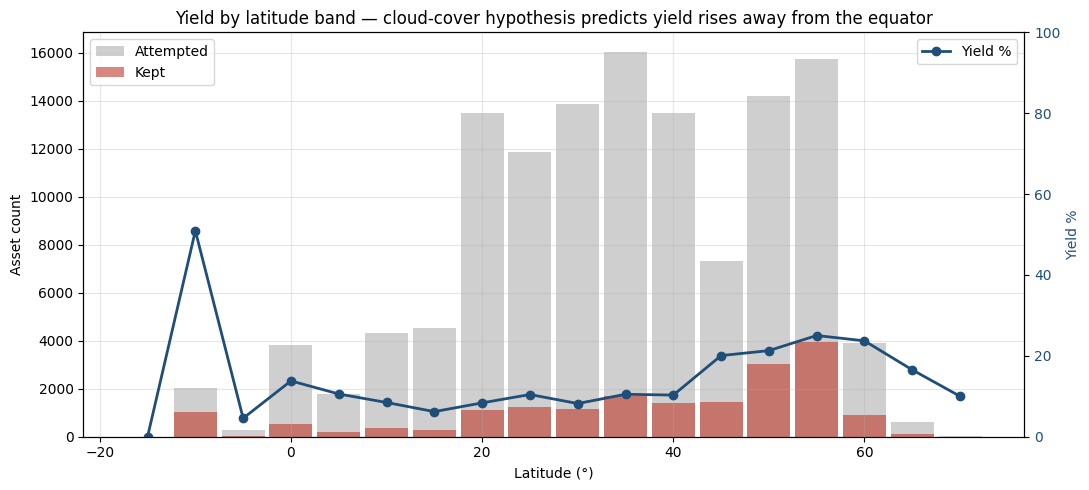


Yield by latitude band:
         attempted  kept  yield_pct
lat_bin                            
-15              4     0   0.000000
-10           2040  1039  50.931373
-5             285    13   4.561404
 0            3817   527  13.806654
 5            1797   190  10.573178
 10           4300   364   8.465116
 15           4543   282   6.207352
 20          13475  1128   8.371058
 25          11843  1236  10.436545
 30          13852  1137   8.208201
 35          16042  1683  10.491211
 40          13485  1389  10.300334
 45           7302  1465  20.062996
 50          14201  3024  21.294275
 55          15730  3937  25.028608
 60           3889   922  23.707894
 65            629   104  16.534181
 70             10     1  10.000000


In [8]:
# 3. Yield by latitude band — the cloud-cover litmus test.
att_by_lat = att_cells.groupby("lat_bin").size().rename("attempted")
fin_by_lat = fin_cells.groupby("lat_bin").size().rename("kept")
lat_df = pd.concat([att_by_lat, fin_by_lat], axis=1).fillna(0).astype(int)
lat_df["yield_pct"] = lat_df["kept"] / lat_df["attempted"] * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(lat_df.index, lat_df["attempted"], width=BIN_DEG * 0.9,
        color="#888888", alpha=0.4, label="Attempted")
ax1.bar(lat_df.index, lat_df["kept"], width=BIN_DEG * 0.9,
        color="#c0392b", alpha=0.6, label="Kept")
ax1.set_xlabel("Latitude (°)")
ax1.set_ylabel("Asset count")
ax1.legend(loc="upper left")

ax2.plot(lat_df.index, lat_df["yield_pct"], "o-",
         color="#1f4e79", linewidth=2, label="Yield %")
ax2.set_ylabel("Yield %", color="#1f4e79")
ax2.tick_params(axis="y", labelcolor="#1f4e79")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right")

ax1.set_title("Yield by latitude band — cloud-cover hypothesis predicts "
              "yield rises away from the equator")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nYield by latitude band:")
print(lat_df.to_string())

### Interpreting Check 1

The latitude-band plot is the cleanest test.

- **Yield rises with absolute latitude (high in 35°N+, low in 0–20°N):** 
  cloud-cover-driven loss confirmed. Defensible to disclose as a documented bias.

- **Yield is uniformly low across all latitudes:** 
  not cloud-driven. Worth investigating before publishing — could be network, 
  API errors, or something in the fetcher itself.

- **Yield is uniformly moderate or high:** 
  the headline 14.7% number is artifact of how it's measured. Worth checking 
  whether the 25,000 attempted denominator is the right baseline.

## Check 2 — Visual spot-check of random tiles

Sample 30 random tiles, render the S2 RGB composite (B04, B03, B02 — the first 
3 channels), inspect.

In [9]:
# Image filenames in summary.csv have format:
#   osm_node_<id>_stac_sentinel2_ms+sentinel1.npy
# The `image_file` column should hold the filename (or full path); resolve it
# against IMAGES_DIR if it's a bare filename.

def resolve_image_path(image_file_value):
    """Resolve summary.csv's image_file value to an actual on-disk path."""
    p = Path(str(image_file_value))
    if p.is_absolute() and p.exists():
        return p
    candidate = IMAGES_DIR / p.name
    if candidate.exists():
        return candidate
    # Last resort: try the value as-is relative to dataset dir
    candidate = DATASET_DIR / p
    if candidate.exists():
        return candidate
    return None

def load_tile_image(row):
    """Return (C, H, W) array for the given summary row, or None."""
    path = resolve_image_path(row["image_file"])
    if path is None:
        return None
    arr = np.load(path)
    return arr

# Quick test on one tile
_test_row = summary.iloc[0]
_test_img = load_tile_image(_test_row)
if _test_img is None:
    print(f"⚠️  Could not load tile for {_test_row['asset_id']}")
    print(f"    image_file value: {_test_row['image_file']}")
    print(f"    Tried: {IMAGES_DIR / Path(str(_test_row['image_file'])).name}")
else:
    print(f"✓ Loaded {_test_row['asset_id']}")
    print(f"    shape={_test_img.shape}, dtype={_test_img.dtype}")
    print(f"    range=[{_test_img.min()}, {_test_img.max()}]")
    print(f"    n_bands from summary={_test_row['n_bands']}, modalities={_test_row['modalities']}")

✓ Loaded osm_node_2760070126
    shape=(9, 61, 61), dtype=float32
    range=[-24.327409744262695, 151.0]
    n_bands from summary=9, modalities=sentinel2_ms+sentinel1


In [10]:
# Sample 30 random tiles
N_SAMPLES = 30
sample = summary.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)

loaded = []
for _, row in sample.iterrows():
    img = load_tile_image(row)
    loaded.append((row, img))

n_loaded = sum(1 for _, img in loaded if img is not None)
print(f"Loaded {n_loaded}/{N_SAMPLES} sample tiles.")

Loaded 30/30 sample tiles.


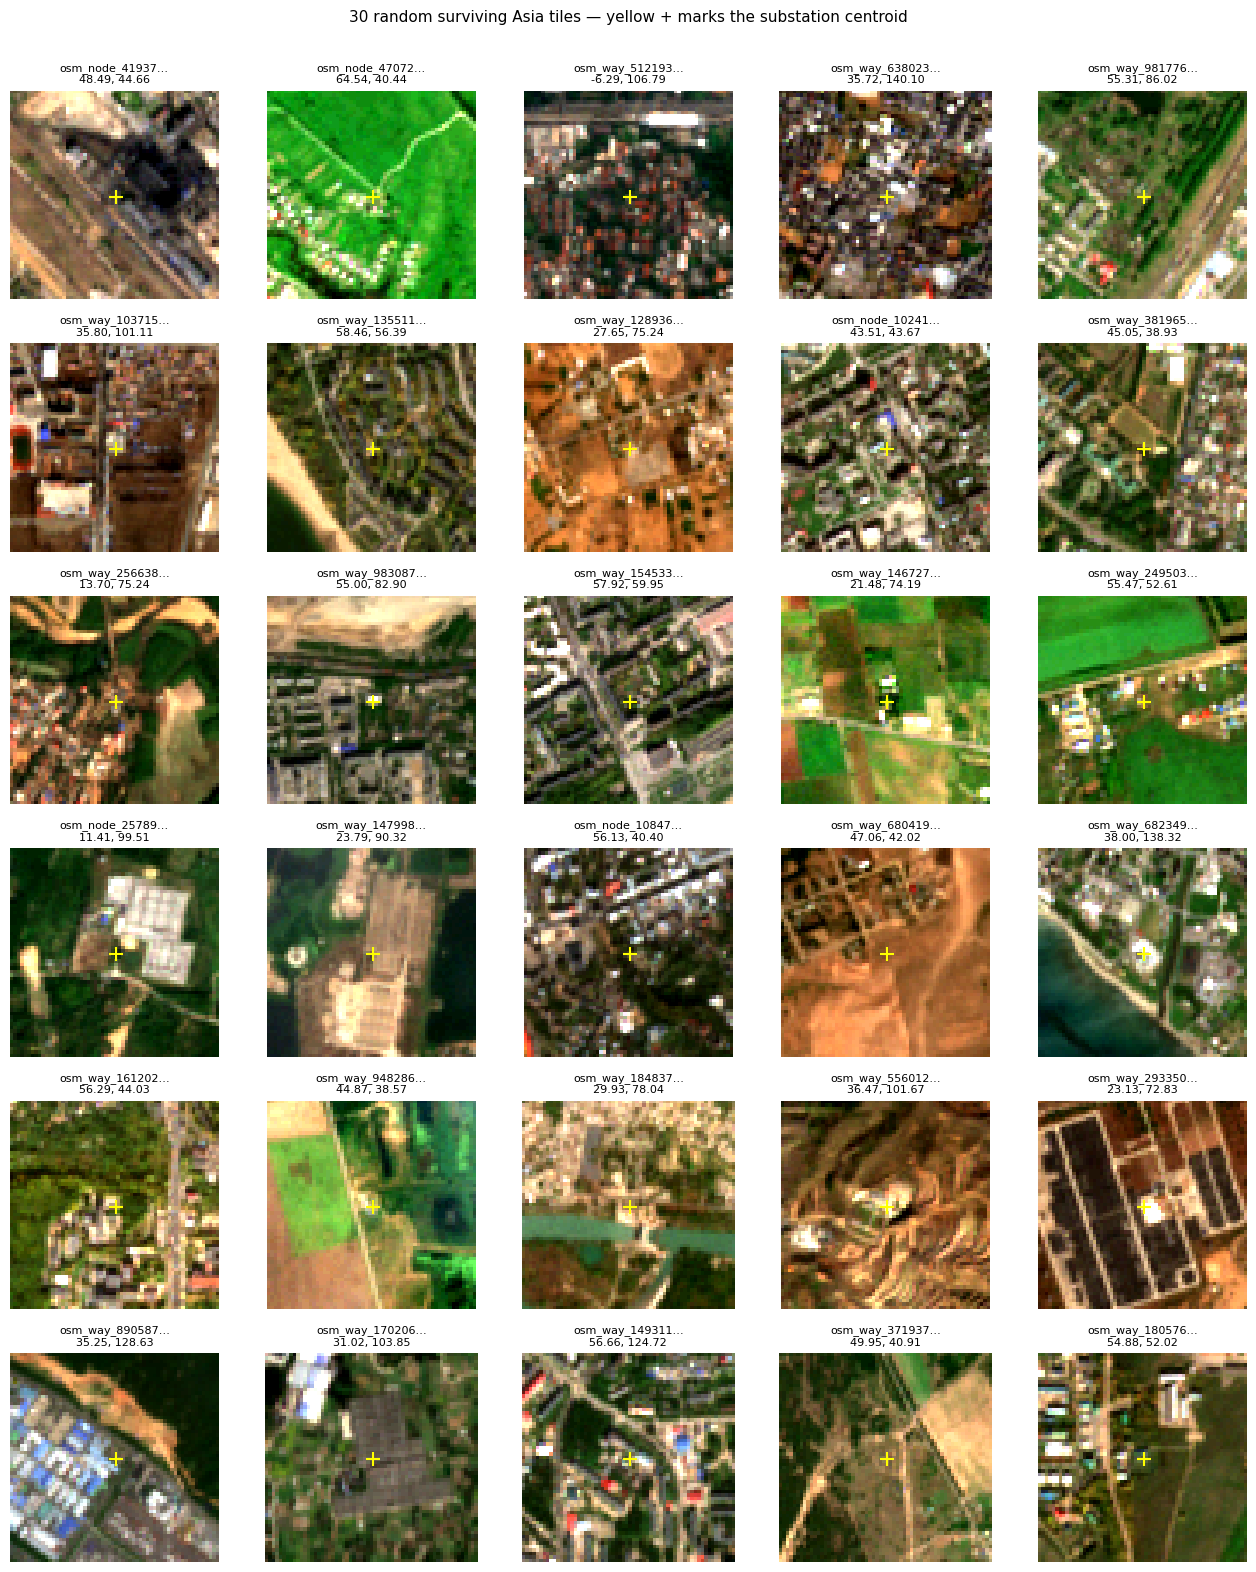

In [11]:
def rgb_from_tile(image, low_pct=2, high_pct=98):
    """
    Build an RGB composite from a (C, H, W) S2-first multimodal tile.
    Band order from stac_imagery.py for sentinel2_ms is
    [B04, B03, B02, B08, B11, B12, B8A], so RGB = channels [0, 1, 2].
    Applies a percentile contrast stretch — substations look very dim otherwise.
    """
    if image is None or image.shape[0] < 3:
        return None
    rgb = image[:3].astype(np.float32)              # (3, H, W) — R, G, B
    rgb = np.transpose(rgb, (1, 2, 0))              # (H, W, 3)
    nonzero = rgb[rgb > 0]
    if nonzero.size == 0:
        return np.zeros_like(rgb, dtype=np.uint8)
    lo, hi = np.percentile(nonzero, [low_pct, high_pct])
    rgb = np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)
    return (rgb * 255).astype(np.uint8)

rows, cols = 6, 5
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
axes = axes.flatten()

for ax, (row, image) in zip(axes, loaded):
    rgb = rgb_from_tile(image)
    if rgb is None:
        ax.text(0.5, 0.5, "no image", ha="center", va="center",
                transform=ax.transAxes)
    else:
        ax.imshow(rgb)
        # Mark the centroid (the substation should be roughly here)
        h, w = rgb.shape[:2]
        ax.plot(w / 2, h / 2, "+", color="yellow", markersize=10, mew=1.5)
    title = f"{row['asset_id'][:14]}…\n{row['lat']:.2f}, {row['lon']:.2f}"
    ax.set_title(title, fontsize=8)
    ax.axis("off")

for ax in axes[len(loaded):]:
    ax.axis("off")

plt.suptitle("30 random surviving Asia tiles — yellow + marks the substation centroid",
             y=1.005, fontsize=11)
plt.tight_layout()
plt.show()

            mean  valid_ratio
count  30.000000         30.0
mean   63.669214          1.0
std    10.102809          0.0
min    36.091030          1.0
25%    58.782738          1.0
50%    63.169348          1.0
75%    68.516857          1.0
max    89.226189          1.0


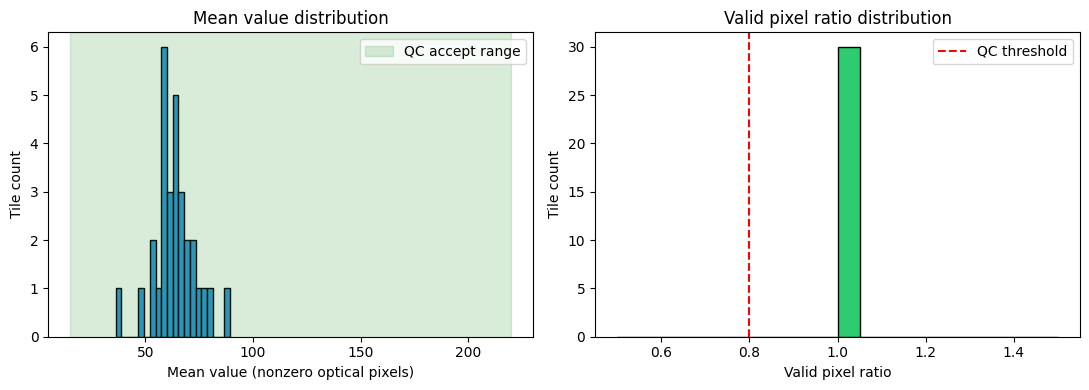

In [12]:
# Numeric distributions for the sample, to surface tiles that just barely passed QC
stats = []
for row, img in loaded:
    if img is None:
        continue
    optical = img[:7]    # S2 7 bands
    nz = optical[optical > 0]
    if nz.size == 0:
        stats.append({"asset_id": row["asset_id"], "mean": 0.0, "valid_ratio": 0.0})
        continue
    valid_mask = np.any(optical != 0, axis=0)
    stats.append({
        "asset_id":    row["asset_id"],
        "mean":        float(nz.mean()),
        "valid_ratio": float(valid_mask.mean()),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(stats_df["mean"], bins=20, color="#3498db", edgecolor="black")
ax1.axvspan(15, 220, alpha=0.15, color="green", label="QC accept range")
ax1.set_xlabel("Mean value (nonzero optical pixels)")
ax1.set_ylabel("Tile count")
ax1.set_title("Mean value distribution")
ax1.legend()

ax2.hist(stats_df["valid_ratio"], bins=20, color="#2ecc71", edgecolor="black")
ax2.axvline(0.80, color="red", linestyle="--", label="QC threshold")
ax2.set_xlabel("Valid pixel ratio")
ax2.set_ylabel("Tile count")
ax2.set_title("Valid pixel ratio distribution")
ax2.legend()

plt.tight_layout()
plt.show()

### Interpreting Check 2

Look at the 6×5 grid of RGB tiles. The yellow `+` marks where the substation 
centroid should be.

- **Most tiles show recognizable substation infrastructure near the centroid** 
  (regular geometric patterns, transmission line connections, cleared land): 
  the tiles are good. Combined with a defensible Check 1, ship the dataset.

- **Tiles look like generic land cover with no obvious infrastructure at the +:** 
  partially expected — substations are small relative to a 600m × 600m tile 
  (your 300m buffer × 2). At 10m S2 resolution, a substation might be 10–30 
  pixels in a 60-pixel tile. You should still see a centered geometric feature 
  in most tiles. If you don't, the OSM substation centroids may be noisy.

- **Multiple tiles look corrupted (heavy striping, blocks of solid color, 
  obvious clouds despite the <20% threshold):** real data quality issue. Worth 
  investigating — check whether the `eo:cloud_cover` metadata is being respected, 
  and whether windowed reads are landing in scene gaps.

Histograms:

- **Mean values clustered between 40–180:** healthy.
- **Mean values near 15 or 220:** edge cases that barely passed QC. Worth 
  individual inspection.
- **Valid ratios near 1.0:** great.
- **Valid ratios concentrated near 0.80:** tiles barely passing. May indicate 
  the threshold should be stricter for journal-quality work.

## Suggested manuscript paragraph

Once both checks are run, adapt this for the dataset documentation section:

> "For the Asia region (n=25,000 attempted assets), 18,441 tiles (73.8% 
> end-to-end yield) survived fetch, QC, and triage. The lower yield relative to 
> other continents reflects the cloud-cover threshold (cloud_cover < 20%) interacting 
> with the persistent cloudiness of equatorial and tropical Asia (Figure X). 
> Per-latitude-band yield ranges from {Y}% in tropical bands (0–20°N) to {Z}% 
> in temperate bands (>30°N). Visual inspection of n=30 randomly sampled tiles 
> confirmed image quality consistent with non-Asian regions; no systematic 
> corruption was detected. Users of the dataset should be aware of the resulting 
> geographic bias toward less-cloudy regions of Asia."

Numbers and figure references to be filled in from your run.